In [10]:
import numpy as np
import pandas as pd
import netwulf as nw
import networkx as nx
import matplotlib.pyplot as plt

In [11]:
pd.set_option('display.max_rows', 500)

In [12]:
connection_pd = pd.read_csv('./line_station_connectionV1130.csv')
connection_pd

,line_cd,station_cd1,station_cd2,company_cd,line_name,station_name1,station_name2,station_lng1,station_lng2,station_lat1,station_lat2,dc:title,odpt:lineCode,odpt:operator,line,odpt_railway,Con,distance
0,11302,1194,976,2,JR山手線,大崎,五反田,139.728439,139.723822,35.619772,35.625974,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,0.735128
1,11302,976,1661,2,JR山手線,五反田,目黒,139.723822,139.715775,35.625974,35.633923,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.120418
2,11302,1661,1885,2,JR山手線,目黒,恵比寿,139.715775,139.710070,35.633923,35.646685,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.254671
3,11302,1885,725,2,JR山手線,恵比寿,渋谷,139.710070,139.701238,35.646685,35.658871,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.425703
4,11302,725,1663,2,JR山手線,渋谷,原宿,139.701238,139.702592,35.658871,35.670646,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.009891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1489,99343,524,889,130,グリーンライン,センター北,北山田,139.578386,139.592258,35.553534,35.561077,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.669461
1490,99343,889,1714,130,グリーンライン,北山田,東山田,139.592258,139.604369,35.561077,35.554302,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.463786
1491,99343,1714,674,130,グリーンライン,東山田,高田,139.604369,139.619944,35.554302,35.549713,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.774937
1492,99343,674,653,130,グリーンライン,高田,日吉本町,139.619944,139.633554,35.549713,35.549883,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.513431


In [42]:
passenger_survey_pd = pd.read_csv('./pass_survey_tokyov1109.csv')
passenger_survey_pd['station_id'] = passenger_survey_pd['station_id'].astype(int)
passenger_survey_pd

,S12_001,2013,2014,2015,2016,2017,2018,2019,station_id
0,あおば通,38882,40922,40820,42664,44052,45302,45302,266
1,あきた白神,54,52,58,54,52,76,76,1551
2,あざみ野,214782,212344,214866,215440,216601,217261,216163,339
3,あしかがフラワーパーク,0,0,0,0,0,0,0,645
4,あつみ温泉,264,266,242,228,238,202,202,1720
...,...,...,...,...,...,...,...,...,...
2479,黒沢,17,14,14,14,12,10,4,68
2480,黒磯,4794,4838,4588,4542,4556,4674,4674,381
2481,鼠ヶ関,0,0,0,0,0,0,0,1839
2482,龍岡城,0,0,0,0,0,0,0,245


In [16]:
station_node_pd = connection_pd[['line', 'station_cd1', 'station_cd2', 'distance']].drop_duplicates()
station_node_pd

,line,station_cd1,station_cd2,distance
0,JR-East.Yamanote,1194,976,0.735128
1,JR-East.Yamanote,976,1661,1.120418
2,JR-East.Yamanote,1661,1885,1.254671
3,JR-East.Yamanote,1885,725,1.425703
4,JR-East.Yamanote,725,1663,1.009891
...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461
1490,YokohamaMunicipal.Green,889,1714,1.463786
1491,YokohamaMunicipal.Green,1714,674,1.774937
1492,YokohamaMunicipal.Green,674,653,1.513431


In [17]:
# testing:

first_row = station_node_pd.loc[(station_node_pd['station_cd1'] == 1194) & (station_node_pd['station_cd2'] == 976)]
second_row = station_node_pd.loc[(station_node_pd['station_cd1'] == 976) & (station_node_pd['station_cd2'] == 1194)]
print(first_row)
print(second_row)

               line  station_cd1  station_cd2  distance
0  JR-East.Yamanote         1194          976  0.735128
Empty DataFrame
Columns: [line, station_cd1, station_cd2, distance]
Index: []


In [ ]:
# build graph structure using networkx
G = nx.Graph()
G = nx.from_pandas_edgelist(station_node_pd, 'station_cd1', 'station_cd2', edge_attr=True)

1299


(<Figure size 480x480 with 1 Axes>, <Axes: >)

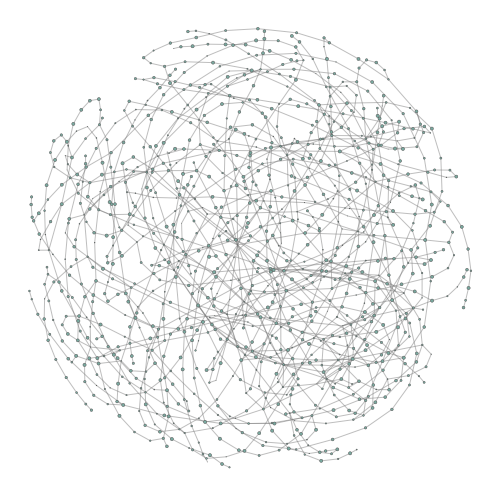

In [21]:
for n, data in G.nodes(data=True):
    data['size'] = np.random.random()

stylized_network, config = nw.visualize(G, plot_in_cell_below=True)

nw.draw_netwulf(stylized_network, config)

In [22]:
#normalize distances
d_max = station_node_pd['distance'].max()
station_node_pd['nor_distance'] = station_node_pd['distance'].apply(lambda x: (x - 0.1) / (d_max - 0.1))
station_node_pd

,line,station_cd1,station_cd2,distance,nor_distance
0,JR-East.Yamanote,1194,976,0.735128,0.048421
1,JR-East.Yamanote,976,1661,1.120418,0.077795
2,JR-East.Yamanote,1661,1885,1.254671,0.088030
3,JR-East.Yamanote,1885,725,1.425703,0.101069
4,JR-East.Yamanote,725,1663,1.009891,0.069368
...,...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461,0.119653
1490,YokohamaMunicipal.Green,889,1714,1.463786,0.103972
1491,YokohamaMunicipal.Green,1714,674,1.774937,0.127694
1492,YokohamaMunicipal.Green,674,653,1.513431,0.107757


In [23]:
#get operator name from line name
#TODO this could be redundant, could just directly get operator instead
station_node_pd['operator'] = station_node_pd['line'].apply(lambda x: x.split('.')[0])
station_node_pd

,line,station_cd1,station_cd2,distance,nor_distance,operator
0,JR-East.Yamanote,1194,976,0.735128,0.048421,JR-East
1,JR-East.Yamanote,976,1661,1.120418,0.077795,JR-East
2,JR-East.Yamanote,1661,1885,1.254671,0.088030,JR-East
3,JR-East.Yamanote,1885,725,1.425703,0.101069,JR-East
4,JR-East.Yamanote,725,1663,1.009891,0.069368,JR-East
...,...,...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461,0.119653,YokohamaMunicipal
1490,YokohamaMunicipal.Green,889,1714,1.463786,0.103972,YokohamaMunicipal
1491,YokohamaMunicipal.Green,1714,674,1.774937,0.127694,YokohamaMunicipal
1492,YokohamaMunicipal.Green,674,653,1.513431,0.107757,YokohamaMunicipal


In [24]:
#let's color lines by operator

operators_list = station_node_pd['operator'].unique()
operators_list.sort()
print("Operators:", operators_list)

colors = range(len(station_node_pd['operator'].unique()))
N=len(colors)

cmap = plt.get_cmap("Set3_r")
cmap_list=[]
for i in range(N):
    c=cmap(float(i)/N)
    cmap_list.append(c)

line_color=dict(zip(operators_list,cmap_list))

line_color

Operators: ['Hokuso' 'JR-East' 'Keikyu' 'Keio' 'Keisei' 'Minatomirai' 'Odakyu'
 'SaitamaRailway' 'Seibu' 'Shibayama' 'ShinKeisei' 'Sotetsu' 'TWR' 'Tobu'
 'Toei' 'TokyoMetro' 'TokyoMonorail' 'Tokyu' 'ToyoRapid'
 'YokohamaMunicipal' 'Yurikamome']


{'Hokuso': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0),
 'JR-East': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0),
 'Keikyu': (0.8, 0.9215686274509803, 0.7725490196078432, 1.0),
 'Keio': (0.8, 0.9215686274509803, 0.7725490196078432, 1.0),
 'Keisei': (0.7372549019607844, 0.5019607843137255, 0.7411764705882353, 1.0),
 'Minatomirai': (0.7372549019607844,
  0.5019607843137255,
  0.7411764705882353,
  1.0),
 'Odakyu': (0.8509803921568627, 0.8509803921568627, 0.8509803921568627, 1.0),
 'SaitamaRailway': (0.9882352941176471,
  0.803921568627451,
  0.8980392156862745,
  1.0),
 'Seibu': (0.9882352941176471, 0.803921568627451, 0.8980392156862745, 1.0),
 'Shibayama': (0.7019607843137254,
  0.8705882352941177,
  0.4117647058823529,
  1.0),
 'ShinKeisei': (0.7019607843137254,
  0.8705882352941177,
  0.4117647058823529,
  1.0),
 'Sotetsu': (0.9921568627450981, 0.7058823529411765, 0.3843137254901961, 1.0),
 'TWR': (0.9921568627450981, 0.7058823529411765, 0.3843137254901961, 1.0),
 'Tobu

In [29]:
for link in stylized_network['links']:
    
    line = station_node_pd[((station_node_pd['station_cd1'] == link['source']) & (station_node_pd['station_cd2'] == link['target'])) |
                           ((station_node_pd['station_cd1'] == link['target']) & (station_node_pd['station_cd2'] == link['source']))]
    # print(line)
    if len(line) > 0:
        print(line)#operator
        #link['color'] = line_color[line.iloc[0, 4]]
        link['color'] = line_color[line.iloc[0, 5]] # 0 takes the first row and 5 takes the operator column. this is fine since if multiple lines go between two stations just pick one of them for the color
        dis = line.iloc[0, 3]
        if dis < 1.0:
            link['width'] = 5
        elif dis < 2.0:
            link['width'] = 4
        elif dis < 5.0:
            link['width'] = 3
        elif dis < 10.0:
            link['width'] = 2
        else:
            link['width'] = 1
    else:
        print(link)
        # if didn't print link, then all the lines have been found

               line  station_cd1  station_cd2  distance  nor_distance operator
0  JR-East.Yamanote         1194          976  0.735128      0.048421  JR-East
                line  station_cd1  station_cd2  distance  nor_distance  \
28  JR-East.Yamanote         1750         1194  1.400128      0.099119   

   operator  
28  JR-East  
                        line  station_cd1  station_cd2  distance  \
296           JR-East.Saikyo         1194         1885  3.063343   
464   JR-East.ShonanShinjuku         1885         1194  3.063343   
1207        Sotetsu.JRDirect         1885         1194  3.063343   

      nor_distance operator  
296       0.225919  JR-East  
464       0.225919  JR-East  
1207      0.225919  Sotetsu  
                        line  station_cd1  station_cd2  distance  \
465   JR-East.ShonanShinjuku         1194          785  1.711485   
1208        Sotetsu.JRDirect         1194          785  1.711485   

      nor_distance operator  
465       0.122856  JR-East  
1208   

In [59]:
for node in stylized_network['nodes']:
    sta = passenger_survey_pd[passenger_survey_pd['station_id'] == node['id']] #node id is station name in english
    print(node['id'], sta.shape[0])
    if len(sta) > 0:
        #node['color'] = line_color[station_node_pd[station_node_pd['station_en'] == node['id']].iloc[0, 4]]
        if station_node_pd[station_node_pd['station_cd1'] == node['id']].empty:
            print("empty")
        try:
            node['color'] = line_color[station_node_pd[station_node_pd['station_cd1'] == node['id']].iloc[0, 5]]
        except Exception as e:
            print("Error")
        sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
        if sta_mean < 10000:
            node['radius'] = 1.5
        elif sta_mean < 100000:
            node['radius'] = 2.5
        elif sta_mean < 500000:
            node['radius'] = 4
        elif sta_mean < 1000000:
            node['radius'] = 7
        elif sta_mean < 2000000:
            node['radius'] = 9
        else:
            node['radius'] = 10
    # elif passenger_survey_pd[passenger_survey_pd['station_cd2'] == node['id']].shape[0] > 0: #some stations only appear in station_cd2 column 
    #     sta = passenger_survey_pd[passenger_survey_pd['station_cd2'] == node['id']]
    #     node['color'] = line_color[station_node_pd[station_node_pd['station_en'] == node['id']].iloc[0, 5]] 
    #     if sta['P_count'].mean() < 10000:
    #         node['radius'] = 1.5
    #     elif sta['P_count'].mean() < 100000:
    #         node['radius'] = 2.5
    #     elif sta['P_count'].mean() < 500000:
    #         node['radius'] = 4
    #     elif sta['P_count'].mean() < 1000000:
    #         node['radius'] = 7
    #     elif sta['P_count'].mean() < 2000000:
    #         node['radius'] = 9
    #     else:
    #         node['radius'] = 10
    else:
        print("station not found in survey data:", node['id'])
    # highlight major stations in green
    if node['id'] in ['Shibuya', 'Shinjuku', 'Ikebukuro', 'Yokohama', 'Takadanobaba', 'Tokyo', 'Shimbashi', 'Shinagawa']:
        node['color'] = "lawngreen"

1194 1
976 1
1661 1
1885 1
725 1
1663 1
1473 1
1872 1
2483 1
1070 1
1871 1
277 1
1707 1
1975 1
1576 1
1859 1
476 1
1142 1
2267 1
881 1
322 1
1344 1
2216 1
2103 1
1077 1
1834 1
161 1
539 1
699 1
1750 1
262 1
606 1
2425 1
1338 1
1462 1
928 1
1248 1
762 1
13 1
1039 1
1895 1
2042 1
318 1
1738 1
2279 1
2277 1
808 1
2356 1
1873 1
1784 1
720 1
612 1
1292 1
538 1
1958 1
1412 1
1234 1
1092 1
1012 1
1620 1
422 1
364 1
2328 1
267 1
1662 1
824 1
2209 1
1404 1
empty
Error
2437 1
2195 1
2264 1
855 1
empty
Error
2215 1
1803 1
943 1
1481 1
2253 1
356 1
503 1
2433 1
1460 1
1842 1
753 1
17 1
1123 1
1979 1
461 1
2491 1
868 1
1820 1
467 1
2293 1
1231 1
1913 1
918 1
1429 1
548 1
1217 1
2374 1
2111 1
1543 1
979 1
1129 1
42 1
27 1
1029 1
1837 1
1611 1
1674 1
87 1
847 1
1061 1
766 1
172 1
2252 1
1562 1
123 1
785 1
1644 1
1102 1
504 1
1369 1
30 1
1265 1
273 1
2435 1
871 1
1992 1
2174 1
1737 1
2401 1
1048 1
empty
Error
2039 1
154 1
1898 1
1480 1
180 1
2001 1
1854 1
1798 1
2405 1
1748 1
2168 1
1970 1
2229 1
1709